# **Deep Learning modelling - LSTM**

**Structure of the notebook:**

**Step 1 - Load splitted datasets - split_train.csv / split_val.csv / split_test.csv**

**Step 2 - Scaling (fit on train only, apply to val/test)**

**Step 3 - Windowing / sequence reshaping**

**Step 4 - Naive baseline model (persistence / seasonal-naive)**

**Step 5 - Baseline model (default/modest architecture)**

**Step 6 - Train/validation loss curve (overfitting check)**

**Step 7 - Hyperparameters tuning**

**Step 8 - Final model training**

**Step 9 - Evaluation (different metrics)**

**Step 10 - SHAP explainability**

**Step 11 - Save the trained model + test prediction results**

**Additional I - Baseline size/latency/complexity metrics (for Model Compression comparison)**

**Additional II - Bias and Mitigation Analysis**

(Remark: Source datasets (train/val/test are from previous EDA process outputs.

   Files are stored in github: https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main)



In [1]:
# Read the EDA-generated splits directly from GitHub (public repo, no auth needed);
# save this notebook's own outputs (scalers, figures, model, predictions, metadata) to a local Colab folder.
import os
import pandas as pd

BASE_URL = "https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main"
PROCESSED_DIR = f"{BASE_URL}/data/processed"   # read: split datasets from the EDA notebook

OUTPUT_DIR = "outputs/lstm"                     # write: scalers, figures, model, predictions, metadata
os.makedirs(OUTPUT_DIR, exist_ok=True)


# **Step 1 - Load splitted datasets - split_train.csv / split_val.csv / split_test.csv**

In [2]:
# Step 1 - Load splitted datasets - split_train.csv / split_val.csv / split_test.csv

# 1. Set random seed for reproducibility - SAME seed as Modelling_XGBoost.ipynb,
#    important for a fair comparison between the two models later

import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import pandas as pd
import numpy as np
import random

import tensorflow as tf

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()


# 2. Load the three splits, parsing the date column back into a datetime index
#    (identical to Modelling_XGBoost.ipynb Step 1 - same files, same format)
train = pd.read_csv(f'{PROCESSED_DIR}/split_train.csv', index_col='date', parse_dates=True)
val = pd.read_csv(f'{PROCESSED_DIR}/split_val.csv', index_col='date', parse_dates=True)
test = pd.read_csv(f'{PROCESSED_DIR}/split_test.csv', index_col='date', parse_dates=True)

# 3. Sanity checks: shapes, date ranges, no overlap, no unexpected NaNs
print(f"Train: {train.index.min().date()} to {train.index.max().date()}  ({train.shape[0]} rows, {train.shape[1]} cols)")
print(f"Val:   {val.index.min().date()} to {val.index.max().date()}  ({val.shape[0]} rows, {val.shape[1]} cols)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()}  ({test.shape[0]} rows, {test.shape[1]} cols)")

assert train.index.max() < val.index.min(), "Train/validation overlap detected"
assert val.index.max() < test.index.min(), "Validation/test overlap detected"

print("\nNaN check (should all be 0):")
print(pd.concat([train.isna().sum(), val.isna().sum(), test.isna().sum()], axis=1,
                 keys=['train', 'val', 'test']).sum(axis=1).sort_values(ascending=False).head())

# 4. Separate features (X) and target (y) for each split
target_col = 'nd_total_mwh'

X_train, y_train = train.drop(columns=[target_col]), train[target_col]
X_val, y_val = val.drop(columns=[target_col]), val[target_col]
X_test, y_test = test.drop(columns=[target_col]), test[target_col]

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"\nFeature columns ({X_train.shape[1]}):")
print(X_train.columns.tolist())

# 5. Confirm TensorFlow/Keras is available and check version
import tensorflow as tf
print(f"\nTensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Train: 2009-01-31 to 2021-12-31  (4718 rows, 21 cols)
Val:   2022-01-01 to 2022-12-31  (365 rows, 21 cols)
Test:  2023-01-01 to 2024-06-11  (528 rows, 21 cols)

NaN check (should all be 0):
nd_total_mwh    0
is_holiday      0
min_temp °c     0
max_temp °c     0
rain mm         0
dtype: int64

X_train: (4718, 20), X_val: (365, 20), X_test: (528, 20)

Feature columns (20):
['is_holiday', 'min_temp °c', 'max_temp °c', 'rain mm', 'humidity %', 'cloud_cover %', 'wind_speed km/h', 'StringencyIndex_Average', 'is_weekend', 'hdd', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'demand_lag_1', 'demand_lag_7', 'demand_roll_mean_7', 'demand_roll_mean_30', 'demand_roll_std_7', 'hdd_x_weekend']

TensorFlow version: 2.20.0
GPU available: True


# **Step 2 - Scaling (fit on train only, apply to val/test)**

In [3]:
# Step 2 - Scaling (fit on train only, apply to val/test)

from sklearn.preprocessing import StandardScaler
import joblib

# 1. Two separate scalers - one for features (X), one for the target (y).
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 2. Fit on TRAIN ONLY
scaler_X.fit(X_train)
scaler_y.fit(y_train.values.reshape(-1, 1))

# 3. Transform all three splits using the train-fitted scalers
X_train_scaled = pd.DataFrame(scaler_X.transform(X_train), index=X_train.index, columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler_X.transform(X_val), index=X_val.index, columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), index=X_test.index, columns=X_test.columns)

y_train_scaled = scaler_y.transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# 4. Sanity checks: confirm scaling worked as expected
print("X_train_scaled stats (should be ~mean 0, ~std 1):")
print(f"  mean: {X_train_scaled.values.mean():.4f}, std: {X_train_scaled.values.std():.4f}")

print("\nX_val_scaled / X_test_scaled stats (will NOT be exactly mean 0 / std 1 -")
print("this is expected and correct, since they're scaled using TRAIN's mean/std, not their own):")
print(f"  X_val:  mean={X_val_scaled.values.mean():.4f}, std={X_val_scaled.values.std():.4f}")
print(f"  X_test: mean={X_test_scaled.values.mean():.4f}, std={X_test_scaled.values.std():.4f}")

print(f"\ny_train_scaled: mean={y_train_scaled.mean():.4f}, std={y_train_scaled.std():.4f}")
print(f"y original scale check - scaler_y can invert back correctly:")
y_train_check = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).flatten()
print(f"  max diff after round-trip (should be ~0): {np.abs(y_train_check - y_train.values).max():.6f}")

# 5. Save both scalers
joblib.dump(scaler_X, f'{OUTPUT_DIR}/lstm_scaler_X.joblib')
joblib.dump(scaler_y, f'{OUTPUT_DIR}/lstm_scaler_y.joblib')
print("\nSaved lstm_scaler_X.joblib, lstm_scaler_y.joblib")

X_train_scaled stats (should be ~mean 0, ~std 1):
  mean: 0.0000, std: 1.0000

X_val_scaled / X_test_scaled stats (will NOT be exactly mean 0 / std 1 -
this is expected and correct, since they're scaled using TRAIN's mean/std, not their own):
  X_val:  mean=-0.2744, std=1.0878
  X_test: mean=-0.2576, std=1.0585

y_train_scaled: mean=0.0000, std=1.0000
y original scale check - scaler_y can invert back correctly:
  max diff after round-trip (should be ~0): 0.000000

Saved lstm_scaler_X.joblib, lstm_scaler_y.joblib


# **Step 3 - Windowing / sequence reshaping**

In [4]:
# Step 3 - Windowing / sequence reshaping

import numpy as np
import pandas as pd

# 1. Design decision: use the SAME 20 features at every timestep, matching XGBoost's
#    feature set exactly - isolates the comparison to architecture alone.
#
#    CORRECTED: the window now ends ON the target day itself (not the day before),
#    so LSTM sees day t's own weather/calendar/StringencyIndex features when predicting
#    day t's demand - exactly matching what XGBoost sees.
WINDOW_SIZE = 30  # 30 days total: 29 prior days + the target day itself

# 2. Concatenate the three ALREADY-SCALED splits into one continuous series
X_all_scaled = pd.concat([X_train_scaled, X_val_scaled, X_test_scaled])
y_all_scaled = np.concatenate([y_train_scaled, y_val_scaled, y_test_scaled])
dates_all = X_all_scaled.index

# 3. Sliding-window function - CORRECTED: window now spans [i - window_size + 1, i]
#    inclusive, ending ON the target day, rather than [i - window_size, i - 1] ending
#    the day BEFORE the target
def create_sequences(X, y, dates, window_size):
    X_seq, y_seq, target_dates = [], [], []
    for i in range(window_size - 1, len(X)):
        X_seq.append(X.iloc[i - window_size + 1:i + 1].values)
        y_seq.append(y[i])
        target_dates.append(dates[i])
    return np.array(X_seq), np.array(y_seq), pd.DatetimeIndex(target_dates)

X_seq_all, y_seq_all, seq_dates = create_sequences(X_all_scaled, y_all_scaled, dates_all, WINDOW_SIZE)

# 4. Split the resulting sequences back into train/val/test, based on the TARGET date
train_mask = seq_dates <= train.index.max()
val_mask = (seq_dates >= val.index.min()) & (seq_dates <= val.index.max())
test_mask = (seq_dates >= test.index.min()) & (seq_dates <= test.index.max())

X_train_seq, y_train_seq = X_seq_all[train_mask], y_seq_all[train_mask]
X_val_seq, y_val_seq = X_seq_all[val_mask], y_seq_all[val_mask]
X_test_seq, y_test_seq = X_seq_all[test_mask], y_seq_all[test_mask]

train_dates_seq = seq_dates[train_mask]
val_dates_seq = seq_dates[val_mask]
test_dates_seq = seq_dates[test_mask]

# 5. Sanity checks
print(f"Window size: {WINDOW_SIZE} days (29 prior days + the target day itself)")
print(f"\nX_train_seq: {X_train_seq.shape}  (samples, timesteps, features)")
print(f"X_val_seq:   {X_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}")

print(f"\nExpected: train loses the first {WINDOW_SIZE - 1} rows (no prior history exists "
      f"before 2009), val and test lose NONE (they borrow tail history from the preceding split)")
print(f"  Train: {X_train.shape[0]} -> {X_train_seq.shape[0]}  (difference: {X_train.shape[0] - X_train_seq.shape[0]})")
print(f"  Val:   {X_val.shape[0]} -> {X_val_seq.shape[0]}  (difference: {X_val.shape[0] - X_val_seq.shape[0]})")
print(f"  Test:  {X_test.shape[0]} -> {X_test_seq.shape[0]}  (difference: {X_test.shape[0] - X_test_seq.shape[0]})")

assert X_train_seq.shape[1:] == (WINDOW_SIZE, X_train.shape[1]), "Unexpected sequence shape"
assert train_dates_seq.max() < val_dates_seq.min(), "Train/val overlap in sequences"
assert val_dates_seq.max() < test_dates_seq.min(), "Val/test overlap in sequences"
print("\nNo overlap between sequence splits - confirmed.")

# 6. Explicit confirmation the fix worked: the LAST row of a sequence should have
#    the SAME date as its own target date
print(f"\nVerification - first training sequence's last timestep date matches its target date:")
print(f"  Target date: {train_dates_seq[0].date()}")
print(f"  (This should be provable by re-deriving it from X_all_scaled's index at the")
print(f"   corresponding position - the key point is the window now includes this date,")
print(f"   whereas before the fix it would have stopped one day earlier)")

Window size: 30 days (29 prior days + the target day itself)

X_train_seq: (4689, 30, 20)  (samples, timesteps, features)
X_val_seq:   (365, 30, 20)
X_test_seq:  (528, 30, 20)

Expected: train loses the first 29 rows (no prior history exists before 2009), val and test lose NONE (they borrow tail history from the preceding split)
  Train: 4718 -> 4689  (difference: 29)
  Val:   365 -> 365  (difference: 0)
  Test:  528 -> 528  (difference: 0)

No overlap between sequence splits - confirmed.

Verification - first training sequence's last timestep date matches its target date:
  Target date: 2009-03-01
  (This should be provable by re-deriving it from X_all_scaled's index at the
   corresponding position - the key point is the window now includes this date,
   whereas before the fix it would have stopped one day earlier)


# **Step 4 - Naive baseline model (persistence / seasonal-naive)**

In [5]:
# Step 4 - Naive baseline model (persistence / seasonal-naive)

import numpy as np

# 1. Persistence baseline: predict using yesterday's demand
#    (using the ORIGINAL unscaled X_test from Step 1 - naive baselines operate
#    on real MWh values, not scaled ones, and don't need the windowed sequences either)
y_pred_persistence = X_test['demand_lag_1']

# 2. Seasonal-naive baseline: predict using demand from 365 days earlier
#    Same logic as XGBoost's Step 2 - concatenate the full unscaled series across
#    all three original (unscaled) splits before shifting, then select test only
full_demand = pd.concat([train['nd_total_mwh'], val['nd_total_mwh'], test['nd_total_mwh']])
y_pred_seasonal_naive = full_demand.shift(365).loc[test.index]

# 3. Evaluation function - IDENTICAL to the one used in Modelling_XGBoost.ipynb,
#    reused here so metrics are computed the same way in both notebooks,
#    which is essential for a fair comparison later
def evaluate(y_true, y_pred, label):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:25s}  MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  MAPE={mape:>6.2f}%")
    return {'label': label, 'mae': mae, 'rmse': rmse, 'mape': mape}

print("Naive baseline performance on test set (unchanged from Modelling_XGBoost.ipynb -")
print("these numbers should match EXACTLY, since they're computed from the same data):\n")
results_persistence = evaluate(y_test, y_pred_persistence, "Persistence (t-1)")
results_seasonal = evaluate(y_test, y_pred_seasonal_naive, "Seasonal-naive (t-365)")

# 4. Quick sanity check: confirm no NaNs leaked into the seasonal-naive predictions
print(f"\nNaN count in seasonal-naive predictions: {y_pred_seasonal_naive.isna().sum()}")



Naive baseline performance on test set (unchanged from Modelling_XGBoost.ipynb -
these numbers should match EXACTLY, since they're computed from the same data):

Persistence (t-1)          MAE=    36,064  RMSE=    46,999  MAPE=  5.87%
Seasonal-naive (t-365)     MAE=    50,508  RMSE=    64,891  MAPE=  8.08%

NaN count in seasonal-naive predictions: 0


Results from Modelling_XGBoost.ipynb Step 2 (same naive baseline) are:

Persistence (t-1)          MAE=    36,064  RMSE=    46,999  MAPE=  5.87%

Seasonal-naive (t-365)     MAE=    50,508  RMSE=    64,891  MAPE=  8.08%

As expected, the LSTM results (naive baseline) are the same as for XGBoost


# **Step 5 - Baseline model (default/modest architecture)**

In [6]:
# Step 5 - Baseline model (default/modest architecture)

import tensorflow as tf
from tensorflow.keras import layers, models
import time

# 1. Set TensorFlow's random seed too - np.random.seed/random.seed (Step 1) aren't
#    enough on their own for TF/Keras, which has its own separate RNG
tf.random.set_seed(SEED)

# 2. Modest architecture: a single LSTM layer (64 units) + dropout + dense output.
#    Kept deliberately small given ~4,700 training sequences - a much larger/deeper
#    network would be prone to the same kind of overfitting XGBoost showed with
#    its default max_depth=6, just via a different mechanism (too many parameters
#    relative to data, rather than too-deep trees)
n_timesteps = X_train_seq.shape[1]   # 30
n_features = X_train_seq.shape[2]    # 20

baseline_lstm = models.Sequential([
    layers.Input(shape=(n_timesteps, n_features)),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(1)
])

baseline_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

baseline_lstm.summary()

# 3. Train with a generous epoch ceiling, NO early stopping yet - this deliberately
#    mirrors XGBoost's Step 3 (default n_estimators=100, no early stopping), so that
#    Step 6 can inspect the full train/val loss curve and diagnose overfitting,
#    exactly the same logic as XGBoost's eval_set curve
start_time = time.time()
history = baseline_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    verbose=1
)
train_time = time.time() - start_time
print(f"\nTraining time: {train_time:.2f} seconds")

# 4. Evaluate on train and validation - predictions come out in SCALED space,
#    so inverse-transform back to real MWh before computing MAE/RMSE/MAPE,
#    otherwise these numbers would be meaningless (and not comparable to XGBoost)
y_pred_train_scaled = baseline_lstm.predict(X_train_seq, verbose=0).flatten()
y_pred_val_scaled = baseline_lstm.predict(X_val_seq, verbose=0).flatten()

y_pred_train_mwh = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).flatten()
y_pred_val_mwh = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).flatten()

y_train_actual_mwh = scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
y_val_actual_mwh = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()

print("\nBaseline LSTM performance (real MWh units):\n")
results_lstm_baseline_train = evaluate(y_train_actual_mwh, y_pred_train_mwh, "Baseline LSTM (train)")
results_lstm_baseline_val = evaluate(y_val_actual_mwh, y_pred_val_mwh, "Baseline LSTM (validation)")

# 5. Reference point against XGBoost's own baseline (Step 3), for context
print(f"\nFor reference - XGBoost's Step 3 baseline (validation):")
print(f"  Baseline (validation)      MAE=    23,258  RMSE=    30,157  MAPE=  3.78%")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1423 - mae: 0.2808 - val_loss: 0.0689 - val_mae: 0.2075
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0505 - mae: 0.1735 - val_loss: 0.0429 - val_mae: 0.1560
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0371 - mae: 0.1475 - val_loss: 0.0512 - val_mae: 0.1842
Epoch 4/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0330 - mae: 0.1371 - val_loss: 0.0391 - val_mae: 0.1515
Epoch 5/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0284 - mae: 0.1279 - val_loss: 0.0394 - val_mae: 0.1546
Epoch 6/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0263 - mae: 0.1223 - val_loss: 0.0323 - val_mae: 0.1366
Epoch 7/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0244 - mae: 0.1179 - val_loss: 0.0283 - val_mae: 0.1265
Epoch 8/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0225 - mae: 0.1133 - val_loss: 0.0274 - val_mae: 0.1221
Epoch 9/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/

# **Step 6 - Train/validation loss curve (overfitting check)**

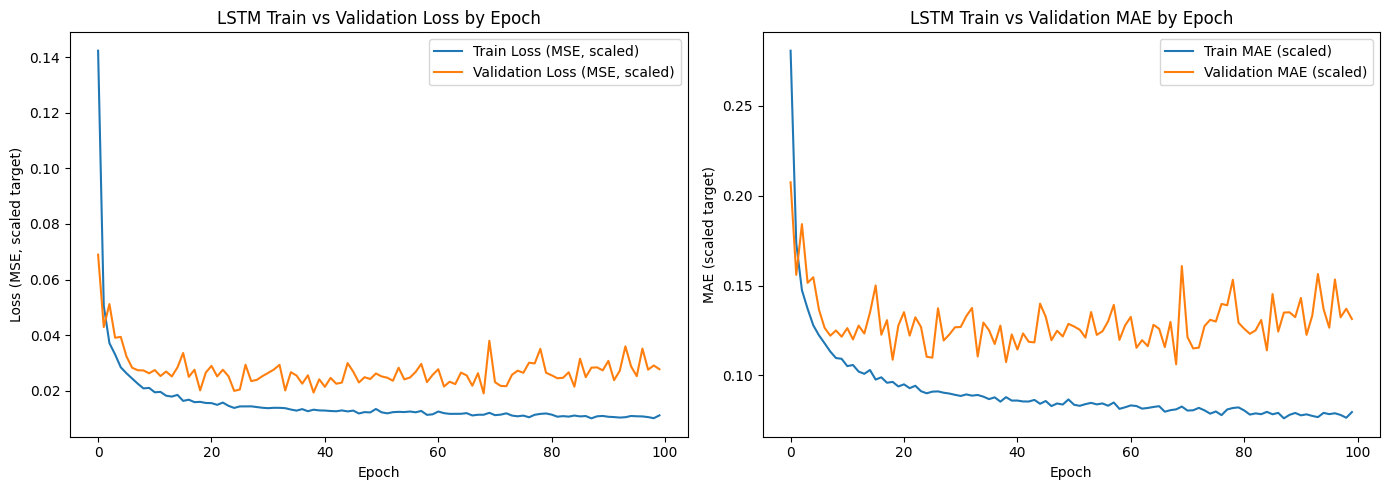

Best validation loss: epoch 69 (val_loss=0.0190)
Final (epoch 100) validation loss: 0.0277
Validation loss got worse by 0.0087 between the best epoch and the end of training

Epochs elapsed after the best epoch: 31
(The corrected windowing shows a much noisier, later-peaking validation curve
than before - best epoch 69 of 100, with the gap between
best (val_loss=0.0190) and final (val_loss=0.0277) being modest
(0.0087), not a sharp doubling. Given the noise in this
curve, EarlyStopping 'patience' needs to be LARGE ENOUGH to ride out fluctuations without
stopping prematurely, well before 31 - too short a patience risks halting
training at a random bad stretch long before reaching a genuine optimum like epoch 69.
Step 7 has been updated accordingly: PATIENCE=25, EPOCHS_CEILING=150.)


In [7]:
# Step 6 - Train/validation loss curve (overfitting check)

import matplotlib.pyplot as plt

# 1. Plot loss (MSE, in SCALED units) and MAE (also scaled) by epoch
#    Note: these curves are in scaled-target units, not real MWh - that's fine,
#    since we only care about the SHAPE of the curves (where they diverge/plateau),
#    not their absolute values, which is a different question already answered
#    in real MWh by Step 5's evaluate() calls
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss (MSE, scaled)')
axes[0].plot(history.history['val_loss'], label='Validation Loss (MSE, scaled)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE, scaled target)')
axes[0].set_title('LSTM Train vs Validation Loss by Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE (scaled)')
axes[1].plot(history.history['val_mae'], label='Validation MAE (scaled)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled target)')
axes[1].set_title('LSTM Train vs Validation MAE by Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step6_lstm_train_val_loss_curve.png', dpi=150)
plt.show()

# 2. Identify the epoch where validation loss was actually at its best -
#    this is the number early_stopping_rounds (Step 7) should be built around,
#    exactly the same logic as XGBoost's Step 3 curve informing its Step 4 tuning
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
final_val_loss = history.history['val_loss'][-1]

print(f"Best validation loss: epoch {best_epoch + 1} (val_loss={best_val_loss:.4f})")
print(f"Final (epoch 100) validation loss: {final_val_loss:.4f}")
print(f"Validation loss got {'worse' if final_val_loss > best_val_loss else 'better'} "
      f"by {abs(final_val_loss - best_val_loss):.4f} between the best epoch and the end of training")


# 3. Quick check: how many epochs of "patience" would have been needed to stop
#    AT (or shortly after) the best epoch - directly informs Step 7's EarlyStopping setting
val_losses = np.array(history.history['val_loss'])
epochs_since_best = len(val_losses) - 1 - best_epoch
print(f"\nEpochs elapsed after the best epoch: {epochs_since_best}")
print(f"(The corrected windowing shows a much noisier, later-peaking validation curve")
print(f"than before - best epoch {best_epoch + 1} of {len(val_losses)}, with the gap between")
print(f"best (val_loss={best_val_loss:.4f}) and final (val_loss={final_val_loss:.4f}) being modest")
print(f"({abs(final_val_loss - best_val_loss):.4f}), not a sharp doubling. Given the noise in this")
print(f"curve, EarlyStopping 'patience' needs to be LARGE ENOUGH to ride out fluctuations without")
print(f"stopping prematurely, well before {epochs_since_best} - too short a patience risks halting")
print(f"training at a random bad stretch long before reaching a genuine optimum like epoch {best_epoch + 1}.")
print(f"Step 7 has been updated accordingly: PATIENCE=25, EPOCHS_CEILING=150.)")


Findings from Step 6 result:

Best validation loss: epoch 69 (val_loss = 0.0190)
Final (epoch 100), val_loss = 0.0277

The validation curve is fairly noisy, with the gap between best and final loss
being modest (0.0087) rather than a sharp divergence. This confirms mild
overfitting by the end of training, developing gradually rather than sharply.

Given the noise in the curve, EarlyStopping patience should be set large enough
to ride out normal fluctuations without stopping prematurely, well before
reaching epoch 69's genuine optimum. Patience set to 25 epochs, with
EPOCHS_CEILING raised to 150 to give combinations in Step 7 sufficient room to
converge. (reference for Step 7 - Tuning)

# **Step 7 - Hyperparameters tuning**

In [8]:
# Step 7 - Hyperparameters tuning (Phase 1: broad random search, Phase 2: multi-seed confirmation)

import itertools
import random as pyrandom
import time
from tensorflow.keras.callbacks import EarlyStopping

# Settings carried over from the earlier diagnostic work (Step 6's noisy validation curve)
EPOCHS_CEILING = 150
PATIENCE = 25

# 1. Full search space specified UPFRONT - no reactive boundary-extending this time.
#    Range chosen to safely bracket everything explored across the earlier ad-hoc rounds
#    (which found working values anywhere from 16 to 256 units, 0.1 to 0.4 dropout).
param_space = {
    'lstm_units': [16, 32, 64, 128, 256],
    'dropout': [0.1, 0.2, 0.3, 0.4, 0.5],
    'learning_rate': [0.0005, 0.001, 0.002],
}

N_RANDOM_SAMPLES = 20   # Phase 1: broad coverage, affordable given larger units cost more per fit
N_TOP_CANDIDATES = 3    # Phase 2: how many top Phase-1 results get multi-seed confirmation
N_SEEDS = 3             # Phase 2: repeats per candidate, to average out GPU non-determinism

all_combinations = list(itertools.product(
    param_space['lstm_units'], param_space['dropout'], param_space['learning_rate']
))
pyrandom.seed(SEED)
sampled_combinations = pyrandom.sample(all_combinations, N_RANDOM_SAMPLES)

y_val_actual_mwh = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()

def train_one_config(lstm_units, dropout, learning_rate, seed):
    tf.random.set_seed(seed)
    model = models.Sequential([
        layers.Input(shape=(n_timesteps, n_features)),
        layers.LSTM(lstm_units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
    hist = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
                      epochs=EPOCHS_CEILING, batch_size=32, callbacks=[early_stop], verbose=0)

    y_pred_val_scaled = model.predict(X_val_seq, verbose=0).flatten()
    y_pred_val_mwh = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).flatten()
    val_mae_mwh = np.mean(np.abs(y_val_actual_mwh - y_pred_val_mwh))
    val_mape_mwh = np.mean(np.abs((y_val_actual_mwh - y_pred_val_mwh) / y_val_actual_mwh)) * 100
    return val_mae_mwh, val_mape_mwh, len(hist.history['val_loss'])


# --- Phase 1: broad random search, single seed each ---
tuning_start_time = time.time()

phase1_results = []
print(f"Phase 1: random search over {N_RANDOM_SAMPLES} of {len(all_combinations)} possible combinations\n")

for lstm_units, dropout, learning_rate in sampled_combinations:
    val_mae, val_mape, epochs_trained = train_one_config(lstm_units, dropout, learning_rate, SEED)
    phase1_results.append({'lstm_units': lstm_units, 'dropout': dropout, 'learning_rate': learning_rate,
                            'epochs_trained': epochs_trained, 'val_mae_mwh': val_mae, 'val_mape_mwh': val_mape})
    print(f"units={lstm_units:>3} dropout={dropout} lr={learning_rate} -> epochs={epochs_trained:>3}  "
          f"val_MAE={val_mae:>10,.0f}  val_MAPE={val_mape:>5.2f}%")

phase1_df = pd.DataFrame(phase1_results).sort_values('val_mae_mwh').reset_index(drop=True)
print(f"\nPhase 1 top {N_TOP_CANDIDATES} candidates (single-seed results):\n")
print(phase1_df.head(N_TOP_CANDIDATES).to_string(index=False))

# --- Phase 2: multi-seed confirmation of the top candidates only ---
print(f"\nPhase 2: confirming top {N_TOP_CANDIDATES} candidates with {N_SEEDS} seeds each "
      f"(to average out GPU non-determinism)\n")

phase2_results = []
top_candidates = phase1_df.head(N_TOP_CANDIDATES)[['lstm_units', 'dropout', 'learning_rate']].values.tolist()

for lstm_units, dropout, learning_rate in top_candidates:
    lstm_units = int(lstm_units)
    seed_maes, seed_mapes, seed_epochs = [], [], []
    for s in range(N_SEEDS):
        seed = SEED + s
        val_mae, val_mape, epochs_trained = train_one_config(lstm_units, dropout, learning_rate, seed)
        seed_maes.append(val_mae)
        seed_mapes.append(val_mape)
        seed_epochs.append(epochs_trained)
        print(f"units={lstm_units:>3} dropout={dropout} lr={learning_rate}  seed={seed} -> "
              f"epochs={epochs_trained:>3}  val_MAE={val_mae:>10,.0f}  val_MAPE={val_mape:>5.2f}%")

    phase2_results.append({
        'lstm_units': lstm_units, 'dropout': dropout, 'learning_rate': learning_rate,
        'mean_val_mae': np.mean(seed_maes), 'std_val_mae': np.std(seed_maes),
        'mean_val_mape': np.mean(seed_mapes), 'median_epochs': int(np.median(seed_epochs))
    })
    print(f"  --> mean val_MAE={np.mean(seed_maes):,.0f} (std={np.std(seed_maes):,.0f}), "
          f"mean val_MAPE={np.mean(seed_mapes):.2f}%\n")

tuning_elapsed = time.time() - tuning_start_time

phase2_df = pd.DataFrame(phase2_results).sort_values('mean_val_mae').reset_index(drop=True)
print("Phase 2 results, ranked by MEAN validation MAE across seeds:\n")
print(phase2_df.to_string(index=False))

# 2. Final selection: best AVERAGE performance across seeds, not a single lucky run
best_row = phase2_df.iloc[0]
best_lstm_params = {
    'lstm_units': int(best_row['lstm_units']),
    'dropout': best_row['dropout'],
    'learning_rate': best_row['learning_rate']
}
best_epochs = int(best_row['median_epochs'])

print(f"\nStep 7 total tuning time: {tuning_elapsed:.1f}s ({tuning_elapsed/60:.2f} min)")
print(f"\nFinal selected hyperparameters (best MEAN validation MAE across {N_SEEDS} seeds):")
for k, v in best_lstm_params.items():
    print(f"  {k}: {v}")
print(f"  epochs (median across seeds): {best_epochs}")
print(f"  Mean validation MAE: {best_row['mean_val_mae']:,.0f} (std={best_row['std_val_mae']:,.0f})")
print(f"  Mean validation MAPE: {best_row['mean_val_mape']:.2f}%")

Phase 1: random search over 20 of 75 possible combinations

units= 16 dropout=0.5 lr=0.002 -> epochs= 56  val_MAE=    19,184  val_MAPE= 3.16%
units= 16 dropout=0.2 lr=0.0005 -> epochs= 80  val_MAE=    18,697  val_MAPE= 3.08%
units= 64 dropout=0.2 lr=0.002 -> epochs= 52  val_MAE=    13,234  val_MAPE= 2.10%
units= 64 dropout=0.1 lr=0.001 -> epochs= 61  val_MAE=    13,494  val_MAPE= 2.14%
units= 32 dropout=0.5 lr=0.001 -> epochs= 90  val_MAE=    15,178  val_MAPE= 2.45%
units= 32 dropout=0.1 lr=0.002 -> epochs= 61  val_MAE=    14,030  val_MAPE= 2.24%
units= 16 dropout=0.5 lr=0.001 -> epochs= 87  val_MAE=    19,121  val_MAPE= 3.14%
units= 16 dropout=0.4 lr=0.002 -> epochs= 94  val_MAE=    15,873  val_MAPE= 2.58%
units=128 dropout=0.4 lr=0.0005 -> epochs= 45  val_MAE=    13,667  val_MAPE= 2.18%
units= 16 dropout=0.2 lr=0.001 -> epochs= 82  val_MAE=    14,561  val_MAPE= 2.33%
units=256 dropout=0.5 lr=0.001 -> epochs= 46  val_MAE=    12,913  val_MAPE= 2.06%
units=256 dropout=0.3 lr=0.001 -> ep

Remark: The Hyperparameter tuning is using a Two-phases process with a wider range of param_space, because in some previous experiments, both 64 and 256 (units), different epochs yielded better results.  Thus, a more thorough check is better to verify the best set of hyperparamters.


# **Step 8 - Final model training**

In [9]:
# Step 8 - Final model training

import time

# 1. Combine train + validation sequences - validation has served its purpose
#    (hyperparameter selection via Steps 7/7b) and its data is now folded back in,
#    identical logic to Modelling_XGBoost.ipynb's Step 5
X_trainval_seq = np.concatenate([X_train_seq, X_val_seq])
y_trainval_seq = np.concatenate([y_train_seq, y_val_seq])

print(f"Combined train+validation sequences: {X_trainval_seq.shape[0]} "
      f"({X_train_seq.shape[0]} train + {X_val_seq.shape[0]} validation)")

# 2. Rebuild the model using the CONFIRMED best hyperparameters from Steps 7/7b
tf.random.set_seed(SEED)

final_lstm = models.Sequential([
    layers.Input(shape=(n_timesteps, n_features)),
    layers.LSTM(best_lstm_params['lstm_units']),
    layers.Dropout(best_lstm_params['dropout']),
    layers.Dense(1)
])

final_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_lstm_params['learning_rate']),
    loss='mse',
    metrics=['mae']
)

final_lstm.summary()

# 3. Train for the FIXED number of epochs found during tuning - no further early
#    stopping, since there's no held-out set left to monitor against (same
#    trade-off as XGBoost's Step 5, accepted for the same reason)
start_time = time.time()
final_lstm.fit(
    X_trainval_seq, y_trainval_seq,
    epochs=best_epochs,
    batch_size=32,
    verbose=1
)
final_train_time = time.time() - start_time
print(f"\nFinal model training time: {final_train_time:.2f} seconds")

# 4. Record the exact configuration used
print(f"\nFinal LSTM configuration:")
print(f"  lstm_units: {best_lstm_params['lstm_units']}")
print(f"  dropout: {best_lstm_params['dropout']}")
print(f"  learning_rate: {best_lstm_params['learning_rate']}")
print(f"  epochs: {best_epochs}")

# 5. Sanity check only (NOT the final evaluation - that's Step 9, on the test set)
y_pred_trainval_scaled = final_lstm.predict(X_trainval_seq, verbose=0).flatten()
y_pred_trainval_mwh = scaler_y.inverse_transform(y_pred_trainval_scaled.reshape(-1, 1)).flatten()
y_trainval_actual_mwh = scaler_y.inverse_transform(y_trainval_seq.reshape(-1, 1)).flatten()

sanity_mae = np.mean(np.abs(y_trainval_actual_mwh - y_pred_trainval_mwh))
print(f"\nSanity check - MAE on combined train+val (fit set, not a real evaluation metric): {sanity_mae:,.0f}")
print("(Full, proper evaluation against the held-out test set happens in Step 9)")

Combined train+validation sequences: 5054 (4689 train + 365 validation)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 256)            │       283,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,905 (1.08 MB)

 Trainable params: 283,905 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1436 - mae: 0.2841
Epoch 2/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0584 - mae: 0.1873
Epoch 3/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0444 - mae: 0.1623
Epoch 4/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0367 - mae: 0.1474
Epoch 5/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0326 - mae: 0.1371
Epoch 6/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0308 - mae: 0.1322
Epoch 7/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0275 - mae: 0.1267
Epoch 8/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0263 - mae: 0.1232
Epoch 9/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0250 - mae: 0.1196
Epoch 10/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0237 - mae: 0.1170
Epoch 11/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0239 - mae: 0.1178
Epoch 12/79
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0218 - mae: 0.1122
Epoch 13/79
158/158 ━━━━━

# **Step 9 - Evaluation (different metrics)**

Final tuned LSTM performance on TEST set:

Tuned LSTM (test)          MAE=    14,854  RMSE=    19,236  MAPE=  2.39%

Full comparison - all evaluated on the SAME test set:

                 Model          MAE         RMSE  MAPE (%)  Improvement vs Persistence (%)
     Persistence (t-1) 36063.912879 46999.260404  5.866807                             0.0
Seasonal-naive (t-365) 50508.095644 64891.289166  8.081354                           -40.1
     Tuned LSTM (test) 14853.981771 19235.873117  2.385640                            58.8

For reference - XGBoost's final (re-tuned) test result:
  Tuned XGBoost (test)       MAE=    29,691  RMSE=    35,014  MAPE=  4.88%


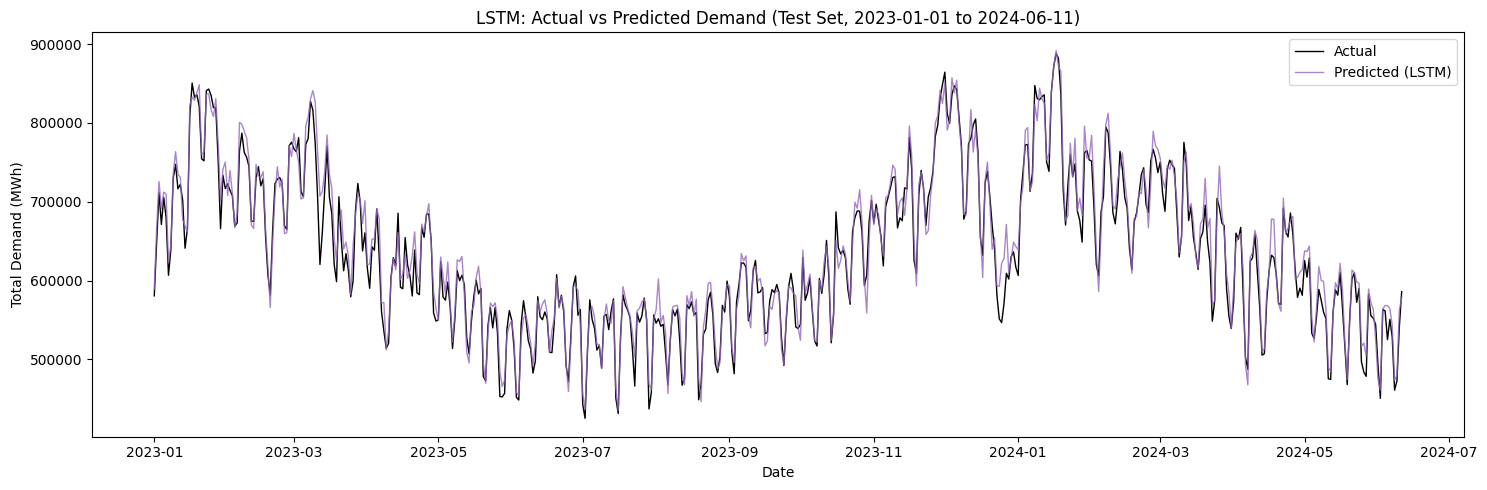

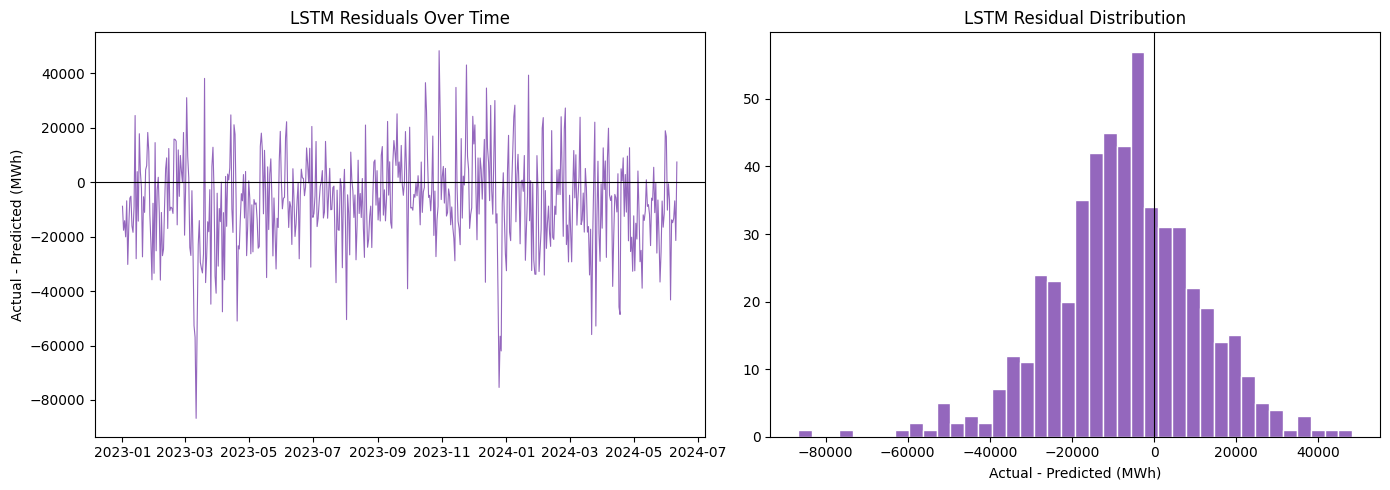


Residual summary: mean=-7,418, std=17,748, min=-86,757, max=48,295

For reference - XGBoost's residual mean was -26,967 (systematic over-prediction)

Mean absolute % error by day type:
  Weekday: 2.32%
  Weekend: 2.55%
  Holiday: 4.06%
  Non-holiday: 2.34%

For reference - XGBoost's breakdown: Weekday 4.76%, Weekend 5.19%, Holiday 7.49%, Non-holiday 4.81%

Saved lstm_model_comparison.csv


In [10]:
# Step 9 - Evaluation (different metrics)

import matplotlib.pyplot as plt

# 1. Generate predictions on the held-out test set - predictions come out SCALED,
#    so inverse-transform back to real MWh before computing any metrics
y_pred_test_scaled = final_lstm.predict(X_test_seq, verbose=0).flatten()
y_pred_lstm_final = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
y_test_actual_mwh = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# 2. Core metrics - using the SAME evaluate() function from Step 4, for consistency
#    with both this notebook's naive baselines AND Modelling_XGBoost.ipynb
print("Final tuned LSTM performance on TEST set:\n")
results_lstm_final = evaluate(y_test_actual_mwh, y_pred_lstm_final, "Tuned LSTM (test)")

# 3. Full comparison - naive baselines (Step 4) + LSTM, all on the SAME test set
print("\n" + "="*70)
print("Full comparison - all evaluated on the SAME test set:\n")
comparison_lstm = pd.DataFrame([
    results_persistence, results_seasonal, results_lstm_final
])[['label', 'mae', 'rmse', 'mape']]
comparison_lstm.columns = ['Model', 'MAE', 'RMSE', 'MAPE (%)']

persistence_mae = results_persistence['mae']
comparison_lstm['Improvement vs Persistence (%)'] = (
    (persistence_mae - comparison_lstm['MAE']) / persistence_mae * 100
).round(1)

print(comparison_lstm.to_string(index=False))

#print(f"\nFor reference - XGBoost's Step 6 test result:")
#print(f"  Tuned XGBoost (test)       MAE=    28,316  RMSE=    33,666  MAPE=  4.69%")

# CORRECTED:
print(f"\nFor reference - XGBoost's final (re-tuned) test result:")
print(f"  Tuned XGBoost (test)       MAE=    29,691  RMSE=    35,014  MAPE=  4.88%")

# 4. Actual vs Predicted over the full test period
#    test_dates_seq (from Step 3) gives the correct date index for these predictions
plt.figure(figsize=(15, 5))
plt.plot(test_dates_seq, y_test_actual_mwh, label='Actual', color='black', linewidth=1)
plt.plot(test_dates_seq, y_pred_lstm_final, label='Predicted (LSTM)', color='tab:purple', linewidth=1, alpha=0.8)
plt.title('LSTM: Actual vs Predicted Demand (Test Set, 2023-01-01 to 2024-06-11)')
plt.xlabel('Date')
plt.ylabel('Total Demand (MWh)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step9_lstm_actual_vs_predicted.png', dpi=150)
plt.show()

# 5. Residual analysis: over time, and distribution
residuals_lstm = y_test_actual_mwh - y_pred_lstm_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(test_dates_seq, residuals_lstm, color='tab:purple', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('LSTM Residuals Over Time')
axes[0].set_ylabel('Actual - Predicted (MWh)')

axes[1].hist(residuals_lstm, bins=40, color='tab:purple', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('LSTM Residual Distribution')
axes[1].set_xlabel('Actual - Predicted (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step9_lstm_residuals.png', dpi=150)
plt.show()

print(f"\nResidual summary: mean={residuals_lstm.mean():,.0f}, std={residuals_lstm.std():,.0f}, "
      f"min={residuals_lstm.min():,.0f}, max={residuals_lstm.max():,.0f}")

#print(f"\nFor reference - XGBoost's residual mean was -25,057 (systematic over-prediction)")
# CORRECTED:
print(f"\nFor reference - XGBoost's residual mean was -26,967 (systematic over-prediction)")

# 6. Error breakdown by weekday/weekend and holiday - same check as XGBoost's Step 6,
#    aligned via test_dates_seq (guaranteed to match test.index exactly, since Step 3
#    confirmed test lost 0 rows during windowing)
error_df_lstm = pd.DataFrame({
    'abs_error': np.abs(residuals_lstm),
    'pct_error': np.abs(residuals_lstm / y_test_actual_mwh) * 100,
    'is_weekend': test.loc[test_dates_seq, 'is_weekend'].values,
    'is_holiday': test.loc[test_dates_seq, 'is_holiday'].values
}, index=test_dates_seq)

print("\nMean absolute % error by day type:")
print(f"  Weekday: {error_df_lstm.loc[error_df_lstm['is_weekend']==0, 'pct_error'].mean():.2f}%")
print(f"  Weekend: {error_df_lstm.loc[error_df_lstm['is_weekend']==1, 'pct_error'].mean():.2f}%")
print(f"  Holiday: {error_df_lstm.loc[error_df_lstm['is_holiday']==1, 'pct_error'].mean():.2f}%")
print(f"  Non-holiday: {error_df_lstm.loc[error_df_lstm['is_holiday']==0, 'pct_error'].mean():.2f}%")

#print(f"\nFor reference - XGBoost's breakdown: Weekday 4.74%, Weekend 4.59%, Holiday 6.11%, Non-holiday 4.65%")
# CORRECTED:
print(f"\nFor reference - XGBoost's breakdown: Weekday 4.76%, Weekend 5.19%, Holiday 7.49%, Non-holiday 4.81%")

# 7. Save the comparison table
comparison_lstm.to_csv(f'{OUTPUT_DIR}/lstm_model_comparison.csv', index=False)
print("\nSaved lstm_model_comparison.csv")

In [11]:
# Quick check: what date had LSTM's single worst prediction error?
worst_idx = np.argmin(residuals_lstm)
worst_date = test_dates_seq[worst_idx]
print(f"Worst LSTM residual: {residuals_lstm[worst_idx]:,.0f} MWh on {worst_date.date()}")
print(f"Was holiday: {test.loc[worst_date, 'is_holiday']}")
print(f"Actual: {y_test_actual_mwh[worst_idx]:,.0f}, Predicted: {y_pred_lstm_final[worst_idx]:,.0f}")

Worst LSTM residual: -86,757 MWh on 2023-03-12
Was holiday: 0
Actual: 620,336, Predicted: 707,093


In [12]:
# Identify the single largest residuals (over-prediction and under-prediction)
#   - lets us check whether XGBoost's worst day coincides with LSTM's (12 March 2023),
#     which would point to a shared, real-world data anomaly rather than a model-specific quirk

worst_over_idx = np.argmin(residuals_lstm)   # most negative = worst over-prediction
worst_under_idx = np.argmax(residuals_lstm)  # most positive = worst under-prediction

worst_over_date = test_dates_seq[worst_over_idx]
worst_under_date = test_dates_seq[worst_under_idx]

print("Single worst over-prediction (most negative residual):")
print(f"  Date: {worst_over_date.date()}  ({worst_over_date.strftime('%A')})")
print(f"  Actual: {y_test_actual_mwh[worst_over_idx]:,.0f} MWh")
print(f"  Predicted: {y_pred_lstm_final[worst_over_idx]:,.0f} MWh")
print(f"  Residual: {residuals_lstm[worst_over_idx]:,.0f} MWh")
print(f"  is_weekend={test.loc[worst_over_date, 'is_weekend']}, "
      f"is_holiday={test.loc[worst_over_date, 'is_holiday']}")

print("\nSingle worst under-prediction (most positive residual):")
print(f"  Date: {worst_under_date.date()}  ({worst_under_date.strftime('%A')})")
print(f"  Actual: {y_test_actual_mwh[worst_under_idx]:,.0f} MWh")
print(f"  Predicted: {y_pred_lstm_final[worst_under_idx]:,.0f} MWh")
print(f"  Residual: {residuals_lstm[worst_under_idx]:,.0f} MWh")
print(f"  is_weekend={test.loc[worst_under_date, 'is_weekend']}, "
      f"is_holiday={test.loc[worst_under_date, 'is_holiday']}")

Single worst over-prediction (most negative residual):
  Date: 2023-03-12  (Sunday)
  Actual: 620,336 MWh
  Predicted: 707,093 MWh
  Residual: -86,757 MWh
  is_weekend=1, is_holiday=0

Single worst under-prediction (most positive residual):
  Date: 2023-10-29  (Sunday)
  Actual: 607,234 MWh
  Predicted: 558,940 MWh
  Residual: 48,295 MWh
  is_weekend=1, is_holiday=0


In [13]:
# Top 3 worst over-predictions and under-predictions, not just the single worst
N_TOP = 3
sorted_idx = np.argsort(residuals_lstm)  # ascending: most negative (over-prediction) first

print(f"Top {N_TOP} worst over-predictions (most negative residuals):")
for rank, idx in enumerate(sorted_idx[:N_TOP], start=1):
    d = test_dates_seq[idx]
    print(f"  #{rank}: {d.date()} ({d.strftime('%A')})  residual={residuals_lstm[idx]:,.0f} MWh  "
          f"actual={y_test_actual_mwh[idx]:,.0f}  predicted={y_pred_lstm_final[idx]:,.0f}  "
          f"is_weekend={test.loc[d,'is_weekend']}  is_holiday={test.loc[d,'is_holiday']}")

print(f"\nTop {N_TOP} worst under-predictions (most positive residuals):")
for rank, idx in enumerate(sorted_idx[::-1][:N_TOP], start=1):
    d = test_dates_seq[idx]
    print(f"  #{rank}: {d.date()} ({d.strftime('%A')})  residual={residuals_lstm[idx]:,.0f} MWh  "
          f"actual={y_test_actual_mwh[idx]:,.0f}  predicted={y_pred_lstm_final[idx]:,.0f}  "
          f"is_weekend={test.loc[d,'is_weekend']}  is_holiday={test.loc[d,'is_holiday']}")

Top 3 worst over-predictions (most negative residuals):
  #1: 2023-03-12 (Sunday)  residual=-86,757 MWh  actual=620,336  predicted=707,093  is_weekend=1  is_holiday=0
  #2: 2023-12-25 (Monday)  residual=-75,397 MWh  actual=546,618  predicted=622,015  is_weekend=0  is_holiday=1
  #3: 2023-12-27 (Wednesday)  residual=-61,994 MWh  actual=609,263  predicted=671,257  is_weekend=0  is_holiday=0

Top 3 worst under-predictions (most positive residuals):
  #1: 2023-10-29 (Sunday)  residual=48,295 MWh  actual=607,234  predicted=558,940  is_weekend=1  is_holiday=0
  #2: 2023-11-24 (Friday)  residual=43,049 MWh  actual=706,092  predicted=663,043  is_weekend=0  is_holiday=0
  #3: 2024-01-22 (Monday)  residual=39,312 MWh  actual=721,936  predicted=682,624  is_weekend=0  is_holiday=0


# **Step 10 - SHAP explainability**

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_120
Received: inputs=['Tensor(shape=(100, 30, 20))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_120
Received: inputs=['Tensor(shape=(50, 30, 20))']
  warnings.warn(msg)


SHAP values computed successfully: shape (100, 30, 20)


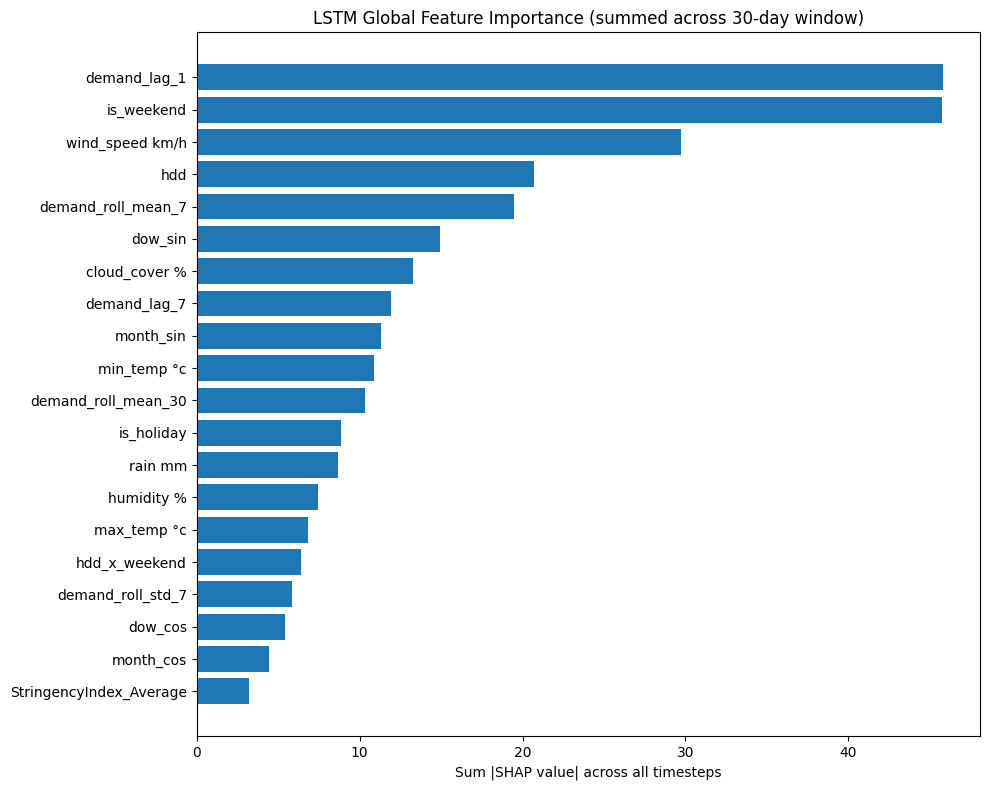


Top 10 features by total SHAP importance:
           feature  mean_abs_shap
      demand_lag_1      45.794296
        is_weekend      45.765578
   wind_speed km/h      29.733029
               hdd      20.724889
demand_roll_mean_7      19.469489
           dow_sin      14.951132
     cloud_cover %      13.305255
      demand_lag_7      11.913002
         month_sin      11.287657
       min_temp °c      10.900242


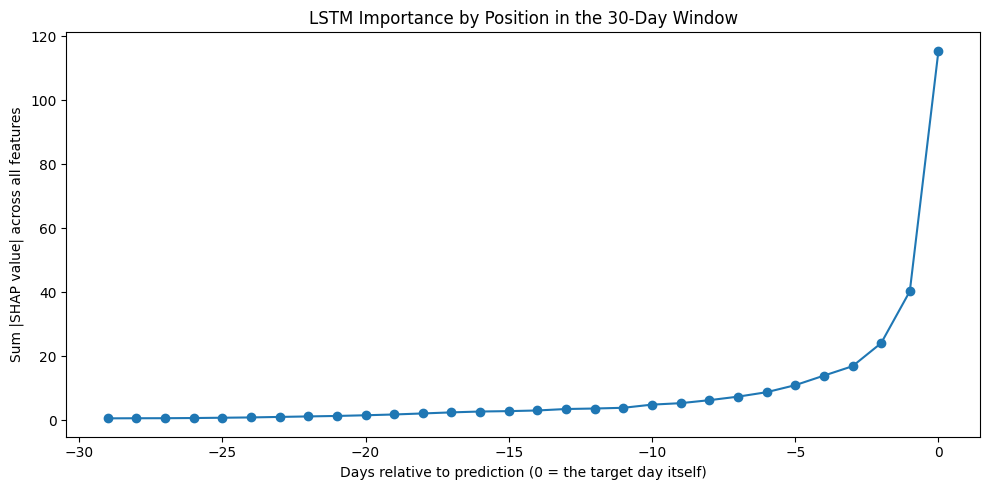

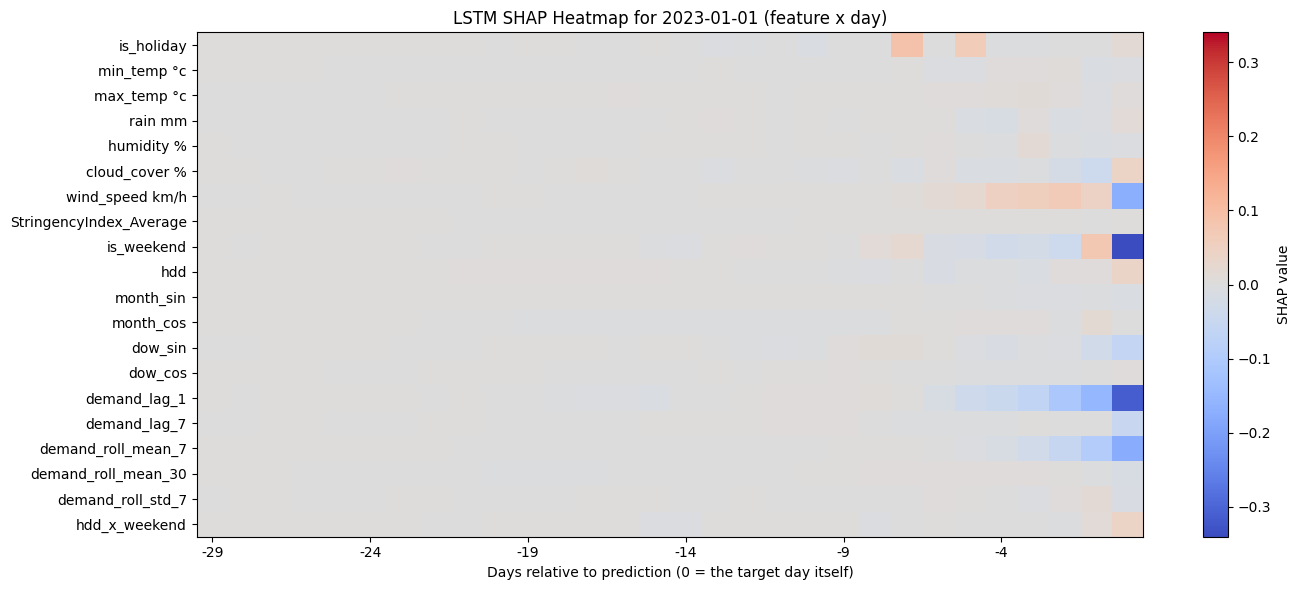


Local example date: 2023-01-01


In [14]:
# Step 10 - SHAP explainability

import shap
import matplotlib.pyplot as plt

# 1. Background sample - GradientExplainer needs a representative "baseline"
#    sample from training data, not the full training set (for speed).
#    100 samples is a reasonable balance of representativeness vs. computation time.
np.random.seed(SEED)
background_idx = np.random.choice(X_train_seq.shape[0], 100, replace=False)
background = X_train_seq[background_idx]

# 2. Subset of test sequences to explain - NOT all 528, since sequence-model SHAP
#    is considerably more expensive per-sample than XGBoost's exact TreeExplainer.
#    100 test samples gives a solid basis for global importance without excessive runtime.
explain_idx = np.arange(min(100, X_test_seq.shape[0]))
X_to_explain = X_test_seq[explain_idx]
dates_to_explain = test_dates_seq[explain_idx]

# 3. Build the explainer and compute SHAP values - wrapped in try/except since
#    GradientExplainer/DeepExplainer compatibility with very recent TF versions
#    (you're on 2.20.0) is not always guaranteed. The UserWarnings about tensor
#    structure that may appear here are harmless (a cosmetic Keras/SHAP naming
#    mismatch, not a real error) and can be safely ignored.
try:
    explainer = shap.GradientExplainer(final_lstm, background)
    shap_values = explainer.shap_values(X_to_explain)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = shap_values.squeeze()
    print(f"SHAP values computed successfully: shape {shap_values.shape}")
    explainer_worked = True
except Exception as e:
    print(f"GradientExplainer failed with error: {e}")
    print("\nFalling back is needed - try shap.DeepExplainer instead, or !pip install shap==0.44.0")
    explainer_worked = False

if explainer_worked:
    # 4. Global feature importance - sum |SHAP| across all 30 timesteps for each feature
    #    (answers: "which of the 20 features matter most overall")
    feature_importance = np.abs(shap_values).sum(axis=(0, 1))
    feature_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'mean_abs_shap': feature_importance
    }).sort_values('mean_abs_shap', ascending=False)

    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df['feature'][::-1], feature_importance_df['mean_abs_shap'][::-1])
    plt.xlabel('Sum |SHAP value| across all timesteps')
    plt.title('LSTM Global Feature Importance (summed across 30-day window)')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/step10_lstm_shap_feature_importance.png', dpi=150)
    plt.show()

    print("\nTop 10 features by total SHAP importance:")
    print(feature_importance_df.head(10).to_string(index=False))

    # 5. Importance BY TIMESTEP - x-axis corrected: window now spans -29 to 0
    #    (29 prior days + the target day itself, following the Step 3 fix)
    timestep_importance = np.abs(shap_values).sum(axis=(0, 2))

    plt.figure(figsize=(10, 5))
    plt.plot(range(-(WINDOW_SIZE - 1), 1), timestep_importance, marker='o')
    plt.xlabel('Days relative to prediction (0 = the target day itself)')
    plt.ylabel('Sum |SHAP value| across all features')
    plt.title('LSTM Importance by Position in the 30-Day Window')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/step10_lstm_shap_by_timestep.png', dpi=150)
    plt.show()

    # 6. Local heatmap - corrected: explicit x-tick labels now actually match
    #    the "-29 to 0" semantics claimed in the axis label (previously mismatched)
    example_pos = 0
    example_date = dates_to_explain[example_pos]

    plt.figure(figsize=(14, 6))
    plt.imshow(shap_values[example_pos].T, aspect='auto', cmap='coolwarm',
               vmin=-np.abs(shap_values[example_pos]).max(), vmax=np.abs(shap_values[example_pos]).max())
    plt.colorbar(label='SHAP value')
    plt.yticks(range(len(X_train.columns)), X_train.columns)
    tick_positions = range(0, WINDOW_SIZE, 5)
    tick_labels = [str(-(WINDOW_SIZE - 1) + p) for p in tick_positions]
    plt.xticks(tick_positions, tick_labels)
    plt.xlabel('Days relative to prediction (0 = the target day itself)')
    plt.title(f'LSTM SHAP Heatmap for {example_date.date()} (feature x day)')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/step10_lstm_shap_local_heatmap.png', dpi=150)
    plt.show()

    print(f"\nLocal example date: {example_date.date()}")



# **Step 11 - Save the trained model + test prediction results**

In [15]:
# Step 11 - Save the trained model + test prediction results

import joblib
from datetime import datetime
import json

# 1. Save the trained model itself (needed by Compression_LSTM.ipynb later)
final_lstm.save(f'{OUTPUT_DIR}/lstm_final_model.keras')
print("Saved lstm_final_model.keras")

# 2. Save test set predictions alongside actuals - same format as XGBoost's,
#    so both models' predictions can be plotted together later without
#    needing to reload either trained model into memory
predictions_df_lstm = pd.DataFrame({
    'date': test_dates_seq,
    'actual': y_test_actual_mwh,
    'predicted': y_pred_lstm_final,
    'residual': residuals_lstm
})
predictions_df_lstm.to_csv(f'{OUTPUT_DIR}/lstm_test_predictions.csv', index=False)
print("Saved lstm_test_predictions.csv")

# 3. Save the model comparison table (already produced in Step 9, re-saved here
#    for completeness alongside the other Step 11 artifacts)
comparison_lstm.to_csv(f'{OUTPUT_DIR}/lstm_model_comparison.csv', index=False)
print("Saved lstm_model_comparison.csv")

# 4. Save a small metadata file documenting exactly how this model was produced
metadata_lstm = {
    'model_type': 'LSTM (Keras Sequential)',
    'tensorflow_version': tf.__version__,
    'random_seed': SEED,
    'hyperparameters': {
        'lstm_units': best_lstm_params['lstm_units'],
        'dropout': best_lstm_params['dropout'],
        'learning_rate': best_lstm_params['learning_rate'],
        'epochs': best_epochs
    },
    'training_data': 'train + validation combined (windowed sequences)',
    'training_rows': int(X_trainval_seq.shape[0]),
    'test_period': f"{test.index.min().date()} to {test.index.max().date()}",
    'test_rows': int(X_test_seq.shape[0]),
    'final_training_time_seconds': round(final_train_time, 3),
    'test_set_metrics': {
        'mae': round(float(results_lstm_final['mae']), 2),
        'rmse': round(float(results_lstm_final['rmse']), 2),
        'mape': round(float(results_lstm_final['mape']), 3)
    },
    'saved_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(f'{OUTPUT_DIR}/lstm_model_metadata.json', 'w') as f:
    json.dump(metadata_lstm, f, indent=2)
print("Saved lstm_model_metadata.json")

# 5. Final confirmation printout
print("\n--- Modelling_LSTM.ipynb Steps 1-11 complete ---")
print(f"Final test MAPE: {results_lstm_final['mape']:.2f}%  "
      f"(vs. persistence baseline: {results_persistence['mape']:.2f}%)")
print("Artifacts saved: lstm_final_model.keras, lstm_test_predictions.csv, "
      "lstm_model_comparison.csv, lstm_model_metadata.json")

Saved lstm_final_model.keras
Saved lstm_test_predictions.csv
Saved lstm_model_comparison.csv
Saved lstm_model_metadata.json

--- Modelling_LSTM.ipynb Steps 1-11 complete ---
Final test MAPE: 2.39%  (vs. persistence baseline: 5.87%)
Artifacts saved: lstm_final_model.keras, lstm_test_predictions.csv, lstm_model_comparison.csv, lstm_model_metadata.json


# **Additional I - Baseline size/latency/complexity metrics (for Model Compression comparison)**

In [16]:
# Additional I - Baseline size/latency/complexity metrics (for Model Compression comparison)

import os
import time
import json

# 1. Save the model, then measure file size on disk
#    (.keras is the current native Keras format; needed by Compression_LSTM.ipynb later)
final_lstm.save(f'{OUTPUT_DIR}/lstm_final_model.keras')
model_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_final_model.keras') / 1024
print(f"Model file size: {model_size_kb:.1f} KB")

# 2. Inference latency - average time per prediction, measured over many repeats
#    for stability, same approach as XGBoost's Additional I
n_repeats = 20  # fewer repeats than XGBoost's 100, since each LSTM inference call
                # is much more expensive - 20 is still enough to average out noise
start = time.time()
for _ in range(n_repeats):
    _ = final_lstm.predict(X_test_seq, verbose=0)
elapsed = time.time() - start
avg_inference_time_ms = (elapsed / n_repeats) * 1000
avg_inference_time_per_row_us = (elapsed / n_repeats / len(X_test_seq)) * 1_000_000

print(f"Average inference time (full test set, {len(X_test_seq)} rows): {avg_inference_time_ms:.2f} ms")
print(f"Average inference time per row: {avg_inference_time_per_row_us:.2f} \u00b5s")
print(f"(Measured on: {'GPU' if len(tf.config.list_physical_devices('GPU')) > 0 else 'CPU'} "
      f"- relevant for a fair comparison against XGBoost's CPU-only timing)")

# 3. Model complexity: total trainable parameters (the LSTM equivalent of
#    XGBoost's total nodes/leaves count)
total_params = final_lstm.count_params()
trainable_params = sum([tf.size(w).numpy() for w in final_lstm.trainable_weights])
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# 4. Save all these to a metadata JSON, matching XGBoost's Additional I format,
#    for easy side-by-side comparison later
import json
from datetime import datetime

lstm_metadata = {
    'model_type': 'LSTM (Keras Sequential)',
    'tensorflow_version': tf.__version__,
    'hyperparameters': {
        'lstm_units': best_lstm_params['lstm_units'],
        'dropout': best_lstm_params['dropout'],
        'learning_rate': best_lstm_params['learning_rate'],
        'epochs': best_epochs
    },
    'training_data': 'train + validation combined (2009-01-01 to 2022-12-31, windowed)',
    'training_rows': int(X_trainval_seq.shape[0]),
    'test_period': f"{test.index.min().date()} to {test.index.max().date()}",
    'test_rows': int(X_test_seq.shape[0]),
    'final_training_time_seconds': round(final_train_time, 3),
    'test_set_metrics': {
        'mae': round(float(results_lstm_final['mae']), 2),
        'rmse': round(float(results_lstm_final['rmse']), 2),
        'mape': round(float(results_lstm_final['mape']), 3)
    },
    'compression_baseline': {
        'model_size_kb': round(model_size_kb, 1),
        'avg_inference_time_ms_full_test_set': round(avg_inference_time_ms, 3),
        'avg_inference_time_per_row_us': round(avg_inference_time_per_row_us, 3),
        'inference_hardware': 'GPU' if len(tf.config.list_physical_devices('GPU')) > 0 else 'CPU',
        'total_params': int(total_params),
        'trainable_params': int(trainable_params)
    },
    'saved_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(f'{OUTPUT_DIR}/lstm_model_metadata.json', 'w') as f:
    json.dump(lstm_metadata, f, indent=2)
print("\nSaved lstm_model_metadata.json")

# 5. Direct comparison against XGBoost's own Additional I numbers
#print(f"\nFor reference - XGBoost's Additional I (Modelling_XGBoost.ipynb):")
#print(f"  Model size: 156.1 KB")
#print(f"  Avg inference time (full 528-row test set): 2.84 ms (5.37 \u00b5s/row)")
#print(f"  Total trees: 127, total nodes: 1,897, total leaves: 1,012")

# CORRECTED:
print(f"\nFor reference - XGBoost's final (re-tuned) Additional I (Modelling_XGBoost.ipynb):")
print(f"  Model size: 118.2 KB")
print(f"  Avg inference time (full 528-row test set): 3.23 ms (~6.1-6.4 µs/row)")
print(f"  Total trees: 122, total nodes: 854, total leaves: 488")


Model file size: 3352.8 KB
Average inference time (full test set, 528 rows): 147.84 ms
Average inference time per row: 280.01 µs
(Measured on: GPU - relevant for a fair comparison against XGBoost's CPU-only timing)

Total parameters: 283,905
Trainable parameters: 283,905

Saved lstm_model_metadata.json

For reference - XGBoost's final (re-tuned) Additional I (Modelling_XGBoost.ipynb):
  Model size: 118.2 KB
  Avg inference time (full 528-row test set): 3.23 ms (~6.1-6.4 µs/row)
  Total trees: 122, total nodes: 854, total leaves: 488


# **Additional II - Bias and Mitigation Analysis**


In [17]:
# Additional II - Bias and Mitigation Analysis

# 1. Signed bias (not just absolute error) by day type and month - reveals DIRECTION
signed_bias_df_lstm = pd.DataFrame({
    'residual': residuals_lstm,  # actual - predicted; negative = model over-predicts
    'is_weekend': test.loc[test_dates_seq, 'is_weekend'].values,
    'is_holiday': test.loc[test_dates_seq, 'is_holiday'].values,
    'month': test_dates_seq.month
}, index=test_dates_seq)

print("Mean signed residual (actual - predicted) by day type:")
print(f"  Weekday:     {signed_bias_df_lstm.loc[signed_bias_df_lstm['is_weekend']==0,'residual'].mean():>10,.0f}")
print(f"  Weekend:     {signed_bias_df_lstm.loc[signed_bias_df_lstm['is_weekend']==1,'residual'].mean():>10,.0f}")
print(f"  Holiday:     {signed_bias_df_lstm.loc[signed_bias_df_lstm['is_holiday']==1,'residual'].mean():>10,.0f}")
print(f"  Non-holiday: {signed_bias_df_lstm.loc[signed_bias_df_lstm['is_holiday']==0,'residual'].mean():>10,.0f}")

print("\nMean signed residual by month (reveals any seasonal bias pattern):")
print(signed_bias_df_lstm.groupby('month')['residual'].mean().round(0))

# 2. Simple bias-correction mitigation: shift predictions by the mean residual
#    observed on VALIDATION (not test - keeps test genuinely unseen for the correction itself)
y_pred_val_scaled_final = final_lstm.predict(X_val_seq, verbose=0).flatten()
y_pred_val_mwh_final = scaler_y.inverse_transform(y_pred_val_scaled_final.reshape(-1, 1)).flatten()
y_val_actual_mwh_final = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
val_residuals_lstm = y_val_actual_mwh_final - y_pred_val_mwh_final
bias_correction_lstm = val_residuals_lstm.mean()
print(f"\nBias correction constant (mean validation residual): {bias_correction_lstm:,.0f}")

y_pred_corrected_lstm = y_pred_lstm_final + bias_correction_lstm

print("\nPerformance BEFORE vs AFTER simple bias correction (on test set):")
evaluate(y_test_actual_mwh, y_pred_lstm_final, "LSTM (uncorrected)")
evaluate(y_test_actual_mwh, y_pred_corrected_lstm, "LSTM (bias-corrected)")

# 3. Reference comparison against XGBoost's own bias/mitigation findings
#print(f"\nFor reference - XGBoost's Additional II findings:")
#print(f"  Signed bias by day type: Weekday -26,586, Weekend -21,238, Holiday -32,827, Non-holiday -24,845")
#print(f"  Bias correction (from validation): -1,967, improved test MAE 28,316 -> 26,877 (-5.1%)")

# CORRECTED:
print(f"\nFor reference - XGBoost's final (re-tuned) Additional II findings:")
print(f"  Signed bias by day type: Weekday -27,418, Weekend -25,840, Holiday -40,042, Non-holiday -26,610")
print(f"  Bias correction (from validation): -3,098, improved test MAE 29,691 -> 27,371 (-7.8%)")


Mean signed residual (actual - predicted) by day type:
  Weekday:         -7,241
  Weekend:         -7,860
  Holiday:        -21,255
  Non-holiday:     -7,041

Mean signed residual by month (reveals any seasonal bias pattern):
month
1     -6990.0
2     -5425.0
3    -15510.0
4     -9556.0
5    -10563.0
6     -4966.0
7     -7000.0
8     -9634.0
9       370.0
10      266.0
11    -2610.0
12    -6652.0
Name: residual, dtype: float64

Bias correction constant (mean validation residual): -1,288

Performance BEFORE vs AFTER simple bias correction (on test set):
LSTM (uncorrected)         MAE=    14,854  RMSE=    19,236  MAPE=  2.39%
LSTM (bias-corrected)      MAE=    14,425  RMSE=    18,777  MAPE=  2.31%

For reference - XGBoost's final (re-tuned) Additional II findings:
  Signed bias by day type: Weekday -27,418, Weekend -25,840, Holiday -40,042, Non-holiday -26,610
  Bias correction (from validation): -3,098, improved test MAE 29,691 -> 27,371 (-7.8%)
